In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
data = pd.read_csv("Student_Performance.csv")
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [23]:
#rename columns
data.columns = data.columns.str.replace(' ', '_')
data.head()

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours_Studied                     10000 non-null  int64  
 1   Previous_Scores                   10000 non-null  int64  
 2   Extracurricular_Activities        10000 non-null  object 
 3   Sleep_Hours                       10000 non-null  int64  
 4   Sample_Question_Papers_Practiced  10000 non-null  int64  
 5   Performance_Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [25]:
data.describe()

,Hours_Studied,Previous_Scores,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [26]:
data.isnull().sum()

Hours_Studied                       0
Previous_Scores                     0
Extracurricular_Activities          0
Sleep_Hours                         0
Sample_Question_Papers_Practiced    0
Performance_Index                   0
dtype: int64

In [27]:
data = data.dropna()

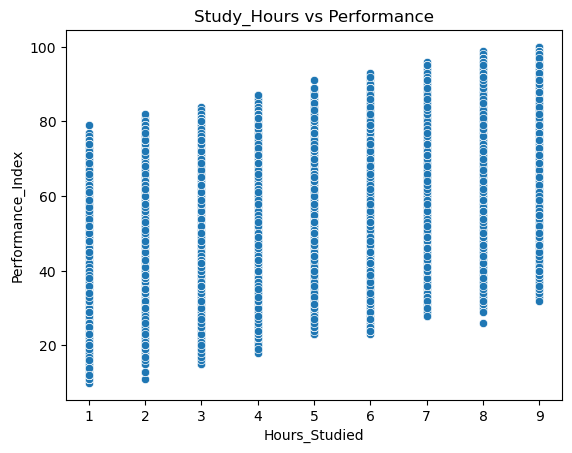

In [28]:
sns.scatterplot(x=data['Hours_Studied'], y=data['Performance_Index'])
plt.title("Study_Hours vs Performance")
plt.show()

In [29]:
data['Extracurricular_Activities'] = data['Extracurricular_Activities'].map({'Yes':1, 'No':0})

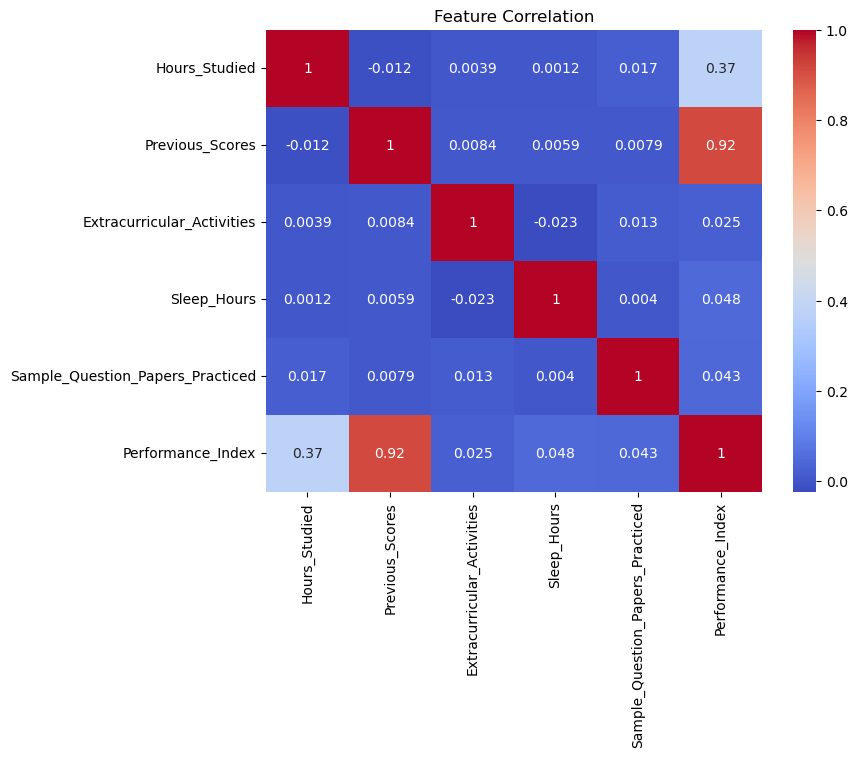

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [31]:
X = data[['Hours_Studied','Previous_Scores','Sleep_Hours','Sample_Question_Papers_Practiced']]
y = data['Performance_Index']

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [34]:
y_pred = model.predict(X_test)

In [35]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9887144552384186
MAE: 1.6296726874197036


In [36]:
import pickle
pickle.dump(model, open("student_model.pkl", "wb"))

In [37]:
def predict_performance(hours, prev_score, sleep, papers):
    # 1. Validate inputs
    if not (1 <= hours <= 12):
        return "Error: Hours Studied must be between 1 and 12"
    
    if not (40 <= prev_score <= 100):
        return "Error: Previous Scores must be between 40 and 100"
    
    if not (4 <= sleep <= 10):
        return "Error: Sleep Hours must be between 4 and 10"
    
    if not (0 <= papers <= 10):
        return "Error: Sample Papers must be between 0 and 10"
        # 2. Format the input as a DataFrame to avoid scikit-learn warnings about missing feature names
    input_df = pd.DataFrame([[hours, prev_score, sleep, papers]], 
                            columns=['Hours_Studied', 'Previous_Scores', 'Sleep_Hours', 'Sample_Question_Papers_Practiced'])   
    # 3. Make the prediction
    prediction = model.predict(input_df)    
    return prediction[0]

In [47]:
predicted_score = predict_performance(hours=4, prev_score=40, sleep=10, papers=1)
print("Predicted Performance Index:", predicted_score)

Predicted Performance Index: 23.41584486397955
